# Odonata Classification V1
## Dragonfly vs Damselfly — Single Species Baseline

**Dataset:** iNaturalist — Dragonflies and Damselflies of Sonoma & Marin Counties  
**Species:** Flame Skimmer (Dragonfly) vs Vivid Dancer (Damselfly)  
**Model:** MobileNetV2 Transfer Learning  
**Note:** This is the baseline model — single species per class, no color jitter  
**Result:** 97.5% validation accuracy, 80% UAE accuracy (misclassified Violet Dropwing)

In [ ]:
!pip install pyinaturalist -q

import os
import requests
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import pyinaturalist

print("✅ Setup complete!")
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.1/141.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.8 MB/s eta 0:00:00
✅ Setup complete!
TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2 — Dataset Exploration
Exploring the iNaturalist Sonoma & Marin Counties project to identify
species with enough observations for training.

In [ ]:
# Count total observations in project
results = pyinaturalist.get_observations(
    project_id="dragonflies-and-damselflies-of-sonoma-marin-counties",
    quality_grade="research",
    photos=True,
    count_only=True
)
print(f"Total research grade observations: {results['total_results']}")

Total research grade observations: 6477


In [ ]:
# Get species breakdown
all_species = Counter()
page = 1

while True:
    results = pyinaturalist.get_observations(
        project_id="dragonflies-and-damselflies-of-sonoma-marin-counties",
        quality_grade="research",
        photos=True,
        per_page=200,
        page=page
    )
    if not results['results']:
        break
    for r in results['results']:
        all_species[r.get('species_guess', 'Unknown')] += 1
    page += 1

print("Top 20 species:")
for species, count in all_species.most_common(20):
    print(f"  {count:4d} → {species}")

Top 20 species:
   652 → Flame Skimmer
   637 → Vivid Dancer
   476 → Variegated Meadowhawk
   462 → Cardinal Meadowhawk
   363 → Pacific Forktail
   343 → Blue-eyed Darner
   342 → Eight-spotted Skimmer
   264 → Widow Skimmer
   264 → Pacific Clubtail
   258 → Blue Dasher
   238 → Common Whitetail
   188 → Pacific Spiketail
   187 → Western Pondhawk
   177 → Common Green Darner
   175 → Grappletail
   120 → California Darner
   108 → Black Saddlebags
    91 → Exclamation Damsel
    82 → Beaverpond Baskettail
    70 → Red-veined Meadowhawk


## Step 3 — Data Download
Downloading 500 images each for:
- **Dragonfly:** Flame Skimmer (651 observations available)
- **Damselfly:** Vivid Dancer (635 observations available)

These two species were chosen for maximum data balance.



In [6]:
def download_species(species_name, label, count=500):
    os.makedirs(f'/content/odonata/{label}', exist_ok=True)
    downloaded = 0
    page = 1

    with tqdm(total=count, desc=f"Downloading {label}") as pbar:
        while downloaded < count:
            results = pyinaturalist.get_observations(
                taxon_name=species_name,
                project_id="dragonflies-and-damselflies-of-sonoma-marin-counties",
                quality_grade="research",
                photos=True,
                per_page=50,
                page=page
            )
            if not results['results']:
                break
            for obs in results['results']:
                if downloaded >= count:
                    break
                try:
                    url = obs['photos'][0]['url'].replace('square', 'medium')
                    response = requests.get(url, timeout=10)
                    if response.status_code == 200:
                        with open(f'/content/odonata/{label}/{label}_{downloaded:04d}.jpg', 'wb') as f:
                            f.write(response.content)
                        downloaded += 1
                        pbar.update(1)
                except:
                    continue
            page += 1
    print(f"✅ {label}: {downloaded} images downloaded")

# Download both species
download_species("Flame Skimmer", "Dragonfly", count=500)
download_species("Vivid Dancer", "Damselfly", count=500)

print(f"\n✅ Dataset complete!")
print(f"Dragonfly: {len(os.listdir('/content/odonata/Dragonfly'))} images")
print(f"Damselfly: {len(os.listdir('/content/odonata/Damselfly'))} images")

✅ Dragonfly: 500 images downloaded


✅ Damselfly: 500 images downloaded

✅ Dataset complete!
Dragonfly: 500 images
Damselfly: 500 images


## Step 4 — Data Preparation
Splitting dataset into 80% training and 20% validation.
No color jitter in V1 — this is the baseline model.

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15
)

train_gen = datagen.flow_from_directory(
    '/content/odonata',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    '/content/odonata',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

print("Class indices:", train_gen.class_indices)
print(f"Train: {train_gen.samples} images")
print(f"Val: {val_gen.samples} images")

Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Class indices: {'Damselfly': 0, 'Dragonfly': 1}
Train: 800 images
Val: 200 images


## Step 5 — Model Building & Training
Using MobileNetV2 pretrained on ImageNet as base model (frozen).
Adding custom classification head for binary output.

In [9]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze pretrained layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)  # binary output

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Model built!")

history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
    ]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model built!
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.8375 - loss: 0.3614 - val_accuracy: 0.9150 - val_loss: 0.1998 - learning_rate: 0.0010
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 561ms/step - accuracy: 0.9525 - loss: 0.1282 - val_accuracy: 0.9500 - val_loss: 0.1269 - learning_rate: 0.0010
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 557ms/step - accuracy: 0.9663 - loss: 0.0865 - val_accuracy: 0.9250 - val_loss: 0.1610 - learning_rate: 0.0010
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9830 - loss: 0.0574
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 545ms/step - accuracy: 0.9787 - loss: 0.0700 - val_accuracy: 0.9450 - val_loss: 0.1410 - learning_rate: 0.0010
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 552ms/step - accuracy: 0.9775 - loss: 0.0646 - val_accuracy: 0.9750 - val_loss: 0.0815 - learning_rate: 5.0000e-04
Epoch 6/10
25/25 ━━

## Step 6 — Evaluation

7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
              precision    recall  f1-score   support

   Damselfly       0.95      0.97      0.96       100
   Dragonfly       0.97      0.95      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



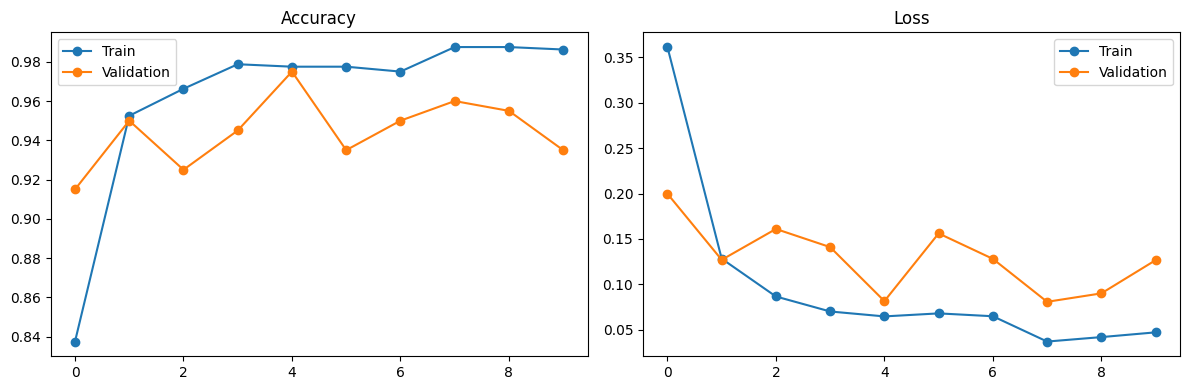

In [10]:
# Classification report
val_gen.reset()
preds = (model.predict(val_gen) > 0.5).astype(int).flatten()
true = val_gen.classes
print(classification_report(true, preds, target_names=['Damselfly', 'Dragonfly']))

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation', marker='o')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[1].plot(history.history['loss'], label='Train', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation', marker='o')
axes[1].set_title('Loss')
axes[1].legend()
plt.tight_layout()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 547ms/step
              precision    recall  f1-score   support

   Damselfly       0.94      0.95      0.95       100
   Dragonfly       0.95      0.94      0.94       100

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.95      0.94      0.94       200



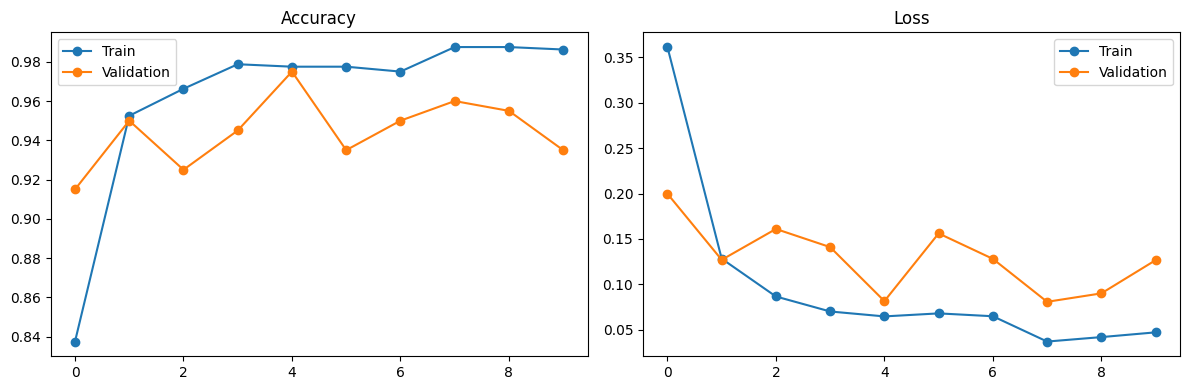

In [11]:

# Classification report
val_gen.reset()
preds = (model.predict(val_gen) > 0.5).astype(int).flatten()
true = val_gen.classes
print(classification_report(true, preds, target_names=['Damselfly', 'Dragonfly']))

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation', marker='o')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[1].plot(history.history['loss'], label='Train', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation', marker='o')
axes[1].set_title('Loss')
axes[1].legend()
plt.tight_layout()
plt.show()

In [12]:
# Save model
os.makedirs('/content/models', exist_ok=True)
model.save('/content/models/odonata_v1.keras')

# Also save to Google Drive
from google.colab import drive
drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/odonata_project', exist_ok=True)
model.save('/content/drive/MyDrive/odonata_project/odonata_v1.keras')
print("✅ Model saved locally and to Google Drive!")

Mounted at /content/drive
✅ Model saved locally and to Google Drive!


## Step 7 — UAE Cross-Regional Testing
Testing V1 model on UAE species from iNaturalist observations.
These species were NOT in the training data — true generalization test.

**Expected finding:** V1 struggles with Violet Dropwing due to color bias.

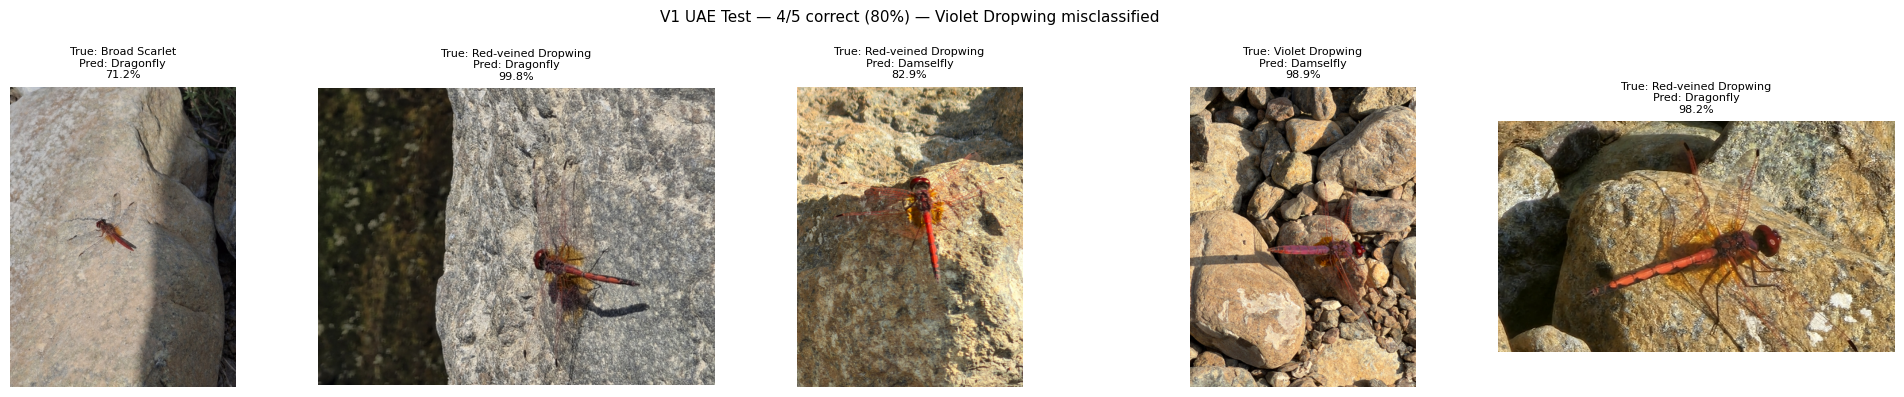

In [13]:
# UAE iNaturalist observations
# Broad Scarlet, Red-veined Dropwing, Violet Dropwing species
obs_ids = [339455646, 338718793, 338861442, 338861507, 338842871]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, obs_id in enumerate(obs_ids):
    result = pyinaturalist.get_observation(obs_id)
    species = result.get('species_guess', 'Unknown')
    photo_url = result['photos'][0]['url'].replace('square', 'medium')

    response = requests.get(photo_url, timeout=10)
    img_path = f'/content/test_{obs_id}.jpg'
    with open(img_path, 'wb') as f:
        f.write(response.content)

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)[0][0]
    predicted = 'Dragonfly' if pred > 0.5 else 'Damselfly'
    confidence = pred if pred > 0.5 else 1 - pred

    axes[i].imshow(image.load_img(img_path))
    axes[i].set_title(
        f'True: {species}\nPred: {predicted}\n{confidence*100:.1f}%',
        fontsize=8)
    axes[i].axis('off')

plt.suptitle('V1 UAE Test — 4/5 correct (80%) — Violet Dropwing misclassified',
             fontsize=11)
plt.tight_layout()
plt.show()